# Laboratorio 7 — ENEIC: entrenamiento final, evaluación en 2026 y análisis de errores

**Alcance:** actividades 7 y 8.

- **Actividad 7.** Se toma la configuración seleccionada en `03_pipelines.ipynb` para cada algoritmo
  (menor RMSE en 2025T4), se reentrena el pipeline completo con **todo 2025** (T1–T4) y se evalúa
  una sola vez en **2026T1**, que no se consultó en ninguna etapa anterior. Ambos modelos y el
  baseline se evalúan sobre exactamente los mismos registros.
- **Actividad 8.** Gráficos de salario real frente a predicho y de residuos, errores por nivel
  educativo y dominio, y análisis por percentiles del salario real.

**Residuo:** `residuo = salario real − salario predicho`. Un residuo **positivo** indica
**subestimación** (el modelo predijo menos de lo real); uno **negativo**, **sobreestimación**.

Las gráficas de dispersión usan una misma muestra de hasta 5,000 registros para ambos modelos;
todas las métricas y tablas por grupo se calculan con **todos** los registros de prueba.
Análisis no ponderado; salarios nominales en quetzales.

In [1]:
from pathlib import Path
import json
import platform

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyspark
from IPython.display import display, Markdown
from pyspark.sql import SparkSession, functions as F
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml.regression import LinearRegression, RandomForestRegressor
from pyspark.ml.evaluation import RegressionEvaluator

ROOT = Path.cwd().resolve()
if ROOT.name.lower() == 'notebooks':
    ROOT = ROOT.parent
OUT = ROOT / 'Transform_Data'
MODELOS = OUT / 'modelos'
MODELOS.mkdir(parents=True, exist_ok=True)
PARQUET_2025 = OUT / 'personas_preparadas_2025'
PARQUET_2026 = OUT / 'personas_preparadas_2026'
SELECCION = OUT / 'seleccion_modelos_validacion.json'

for ruta, notebook in [(PARQUET_2025, '01_preparacion_eneic'), (PARQUET_2026, '01_preparacion_eneic'),
                       (SELECCION, '03_pipelines')]:
    assert ruta.exists(), f'No existe {ruta.relative_to(ROOT)}. Ejecute primero {notebook}.ipynb de principio a fin.'
assert pyspark.__version__.startswith('3.5.'), f'Se requiere PySpark 3.5.x; actual: {pyspark.__version__}'

spark = (SparkSession.builder
         .master('local[2]')
         .appName('L07_ENEIC_Evaluacion_Final')
         .config('spark.sql.shuffle.partitions', '8')
         .config('spark.sql.ansi.enabled', 'false')
         .config('spark.driver.memory', '2g')
         .getOrCreate())
spark.sparkContext.setLogLevel('WARN')
plt.rcParams.update({'figure.figsize': (9, 4), 'axes.spines.top': False, 'axes.spines.right': False})

ETIQUETA = 'salario_mensual'
NUMERICAS = ['edad', 'antiguedad', 'horas_semanales']
CATEGORICAS = ['nivel_educativo', 'categoria_ocupacional', 'dominio']
PREDICTORES = NUMERICAS + CATEGORICAS
CLAVE = ['NUM_HOGAR', 'NUM_PERSONA']
TAMANIO_MUESTRA = 5000

seleccion = json.loads(SELECCION.read_text(encoding='utf-8'))
config_lr, config_rf, config_base = seleccion['regresion_lineal'], seleccion['random_forest'], seleccion['baseline']
SEMILLA = int(seleccion['semilla_random_forest'])

def explicar(texto):
    display(Markdown(texto))

def guardar_grafica(nombre):
    plt.tight_layout()
    plt.savefig(OUT / f'{nombre}.png', dpi=160, bbox_inches='tight')
    plt.show()

def tabla(df, nombre):
    # Sólo tablas agregadas, nunca la base analítica completa.
    assert len(df) <= 10000
    display(df)
    df.to_csv(OUT / f'{nombre}.csv', index=False)

def etiquetas_diccionario(variable):
    # Etiquetas del diccionario guardadas por el notebook 01.
    ruta = OUT / f'distribucion_{variable}_2025.csv'
    if not ruta.exists():
        return {}
    d = pd.read_csv(ruta, dtype={variable: str})
    return dict(zip(d[variable], d.etiqueta.str.strip().str.rstrip('?').str.strip()))

print('Python:', platform.python_version(), '| Spark:', spark.version)
print('Regresión lineal seleccionada:', config_lr['configuracion'],
      f"(regParam={config_lr['regParam']}, elasticNetParam={config_lr['elasticNetParam']})")
print('Random Forest seleccionado:', config_rf['configuracion'],
      f"(numTrees={config_rf['numTrees']}, maxDepth={config_rf['maxDepth']}, seed={SEMILLA})")

/usr/local/lib/python3.11/site-packages/pyspark/bin/load-spark-env.sh: line 68: ps: command not found


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


26/09/26 20:16:42 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


26/09/26 20:16:42 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


Python: 3.11.16 | Spark: 3.5.1
Regresión lineal seleccionada: sin_regularizacion (regParam=0.0, elasticNetParam=0.0)
Random Forest seleccionado: rf_100_arboles_d14 (numTrees=100, maxDepth=14, seed=2026)


## 7. Entrenamiento final y evaluación en 2026T1

### 7.1 Conjuntos
El entrenamiento final usa los cuatro trimestres de 2025. La prueba es 2026T1, preparada en el
notebook 01 con **las mismas reglas** (período por archivo, códigos validados contra el diccionario y
los mismos filtros de población y calidad). Se verifican los mismos controles que en el notebook 03.

In [2]:
def cargar(ruta):
    df = spark.read.parquet(str(ruta))
    faltan = sorted(set(CLAVE + [ETIQUETA] + PREDICTORES) - set(df.columns))
    assert not faltan, f'Faltan columnas requeridas en {ruta.name}: {faltan}'
    return df.select('periodo_archivo', *CLAVE, ETIQUETA, *PREDICTORES)

def controles(df, nombre):
    r = df.agg(
        *[F.sum(F.when(F.col(c).isNull(), 1).otherwise(0)).alias(c + '_nulos') for c in [ETIQUETA] + PREDICTORES],
        *[F.sum(F.when(F.isnan(c) | (F.abs(F.col(c)) == float('inf')), 1).otherwise(0)).alias(c + '_no_finitos')
          for c in [ETIQUETA] + NUMERICAS]
    ).first().asDict()
    problemas = {k: int(v) for k, v in r.items() if v}
    assert not problemas, f'{nombre} contiene valores inválidos: {problemas}'

entrenamiento_final = cargar(PARQUET_2025).cache()
prueba = cargar(PARQUET_2026).cache()
controles(entrenamiento_final, 'Entrenamiento 2025')
controles(prueba, 'Prueba 2026T1')

n_entrenamiento = entrenamiento_final.count()
n_prueba = prueba.count()
assert prueba.select(*CLAVE).distinct().count() == n_prueba, 'La clave hogar-persona debe ser única en 2026T1.'
periodos_prueba = [r[0] for r in prueba.select('periodo_archivo').distinct().collect()]
assert periodos_prueba == ['2026T1'], periodos_prueba

display(pd.DataFrame([
    {'conjunto': 'Entrenamiento final', 'periodos': '2025T1–2025T4', 'registros': n_entrenamiento},
    {'conjunto': 'Prueba', 'periodos': '2026T1', 'registros': n_prueba},
]))

cobertura = []
for variable in CATEGORICAS:
    en_2025 = {r[0] for r in entrenamiento_final.select(variable).distinct().collect()}
    en_2026 = {r[0] for r in prueba.select(variable).distinct().collect()}
    nuevas = sorted(en_2026 - en_2025)
    cobertura.append({'variable': variable, 'categorias_2025': len(en_2025), 'categorias_2026': len(en_2026),
                      'categorias_nuevas_en_2026': ', '.join(nuevas) if nuevas else 'Ninguna'})
display(pd.DataFrame(cobertura))

,conjunto,periodos,registros
0,Entrenamiento final,2025T1–2025T4,53025
1,Prueba,2026T1,13258


,variable,categorias_2025,categorias_2026,categorias_nuevas_en_2026
0,nivel_educativo,8,8,Ninguna
1,categoria_ocupacional,4,4,Ninguna
2,dominio,3,3,Ninguna


Si 2026 trajera una categoría no vista en 2025, `handleInvalid="keep"` la asignaría a un índice reservado en lugar de detener la predicción.

### 7.2 Reentrenamiento con la configuración seleccionada

Los hiperparámetros se leen de `seleccion_modelos_validacion.json` (no se eligen de nuevo con 2026).
El preprocesamiento es el mismo del notebook 03 y se ajusta **sólo con 2025**; 2026 únicamente se transforma.

In [3]:
def etapas_preprocesamiento(output_features='features'):
    columnas_indices = [f'{c}_indice' for c in CATEGORICAS]
    columnas_ohe = [f'{c}_ohe' for c in CATEGORICAS]
    indexadores = [
        StringIndexer(inputCol=entrada, outputCol=salida, handleInvalid='keep', stringOrderType='alphabetAsc')
        for entrada, salida in zip(CATEGORICAS, columnas_indices)
    ]
    codificador = OneHotEncoder(
        inputCols=columnas_indices, outputCols=columnas_ohe, handleInvalid='keep', dropLast=True
    )
    ensamblador = VectorAssembler(
        inputCols=NUMERICAS + columnas_ohe, outputCol=output_features, handleInvalid='error'
    )
    return indexadores + [codificador, ensamblador]

pipeline_lr = Pipeline(stages=etapas_preprocesamiento() + [LinearRegression(
    featuresCol='features', labelCol=ETIQUETA, predictionCol='prediction',
    standardization=True, fitIntercept=True, maxIter=100, tol=1e-6,
    regParam=float(config_lr['regParam']), elasticNetParam=float(config_lr['elasticNetParam']),
)])
pipeline_rf = Pipeline(stages=etapas_preprocesamiento() + [RandomForestRegressor(
    featuresCol='features', labelCol=ETIQUETA, predictionCol='prediction',
    numTrees=int(config_rf['numTrees']), maxDepth=int(config_rf['maxDepth']), seed=SEMILLA,
    subsamplingRate=0.8, featureSubsetStrategy='auto', maxBins=32, minInstancesPerNode=2,
)])

modelo_lr = pipeline_lr.fit(entrenamiento_final)
modelo_rf = pipeline_rf.fit(entrenamiento_final)
media_2025 = float(entrenamiento_final.agg(F.mean(ETIQUETA)).first()[0])

modelo_lr.write().overwrite().save(str(MODELOS / 'final_regresion_lineal'))
modelo_rf.write().overwrite().save(str(MODELOS / 'final_random_forest'))
print('Baseline (media salarial de 2025):', f'Q{media_2025:,.2f}')
print('Modelos finales guardados en:', MODELOS)

26/09/26 20:16:53 WARN Instrumentation: [195d6729] regParam is zero, which might cause numerical instability and overfitting.


26/09/26 20:16:54 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS
26/09/26 20:16:54 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.VectorBLAS
26/09/26 20:16:54 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.lapack.JNILAPACK
26/09/26 20:16:54 WARN Instrumentation: [195d6729] Cholesky solver failed due to singular covariance matrix. Retrying with Quasi-Newton solver.


26/09/26 20:17:02 WARN DAGScheduler: Broadcasting large task binary with size 1073.2 KiB


26/09/26 20:17:04 WARN DAGScheduler: Broadcasting large task binary with size 1884.0 KiB


26/09/26 20:17:05 WARN DAGScheduler: Broadcasting large task binary with size 3.2 MiB


...

26/09/26 20:17:33 WARN DAGScheduler: Broadcasting large task binary with size 3.8 MiB


26/09/26 20:17:35 WARN DAGScheduler: Broadcasting large task binary with size 31.6 MiB


26/09/26 20:17:41 WARN DAGScheduler: Broadcasting large task binary with size 4.2 MiB


26/09/26 20:18:07 WARN TaskSetManager: Stage 142 contains a task of very large size (10591 KiB). The maximum recommended task size is 1000 KiB.


Baseline (media salarial de 2025): Q3,421.68
Modelos finales guardados en: /opt/app/laboratorio/Transform_Data/modelos


### 7.3 Predicciones sobre los mismos registros

Cada modelo transforma el mismo DataFrame de prueba y las predicciones se unen por la clave
hogar–persona. Se verifica que ninguna fila se pierda ni quede sin predicción.

In [4]:
def predecir(modelo, columna):
    return modelo.transform(prueba).select(*CLAVE, F.col('prediction').alias(columna))

predicciones = (prueba.select(*CLAVE, ETIQUETA, *PREDICTORES)
    .join(predecir(modelo_lr, 'pred_lr'), CLAVE, 'inner')
    .join(predecir(modelo_rf, 'pred_rf'), CLAVE, 'inner')
    .withColumn('pred_baseline', F.lit(media_2025))
    .withColumn('residuo_lr', F.col(ETIQUETA) - F.col('pred_lr'))
    .withColumn('residuo_rf', F.col(ETIQUETA) - F.col('pred_rf'))
    .cache())

n_predicciones = predicciones.count()
sin_prediccion = predicciones.filter(F.col('pred_lr').isNull() | F.col('pred_rf').isNull()).count()
assert n_predicciones == n_prueba and sin_prediccion == 0, (n_predicciones, n_prueba, sin_prediccion)
predicciones.write.mode('overwrite').parquet(str(OUT / 'predicciones_2026T1'))

Los tres modelos se evalúan sobre los mismos **13,258 registros** de 2026T1. La regresión lineal produce **29 predicciones menores o iguales a cero**; se conservan en las métricas porque son parte del comportamiento real del modelo.

### 7.4 Métricas en 2026T1

,modelo,configuracion,mae_prueba,rmse_prueba,r2_prueba,rmse_validacion_2025T4,r2_validacion_2025T4,mejora_rmse_vs_baseline_pct,cambio_rmse_vs_validacion_pct
0,Baseline,Media del entrenamiento,1718.086005,2871.420677,-0.002525,2889.571432,-0.003132,0.000000,-0.628147
1,Regresión lineal,sin_regularizacion,1240.710547,2163.751703,0.430732,2186.419579,0.425675,24.645256,-1.036758
2,Random Forest,rf_100_arboles_d14,1083.520618,1929.426907,0.547354,1959.452972,0.538724,32.805843,-1.532370


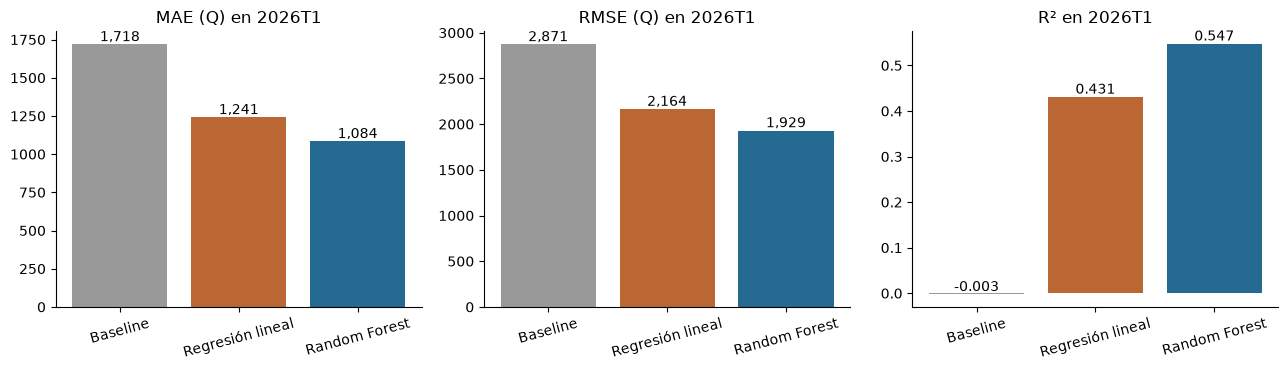

In [5]:
MODELOS_EVALUADOS = {'Baseline': ('pred_baseline', config_base),
                     'Regresión lineal': ('pred_lr', config_lr),
                     'Random Forest': ('pred_rf', config_rf)}

def calcular_metricas(columna):
    return {m: float(RegressionEvaluator(labelCol=ETIQUETA, predictionCol=columna, metricName=m).evaluate(predicciones))
            for m in ['mae', 'rmse', 'r2']}

filas = []
for nombre, (columna, config) in MODELOS_EVALUADOS.items():
    m = calcular_metricas(columna)
    filas.append({'modelo': nombre, 'configuracion': config['configuracion'],
                  'mae_prueba': m['mae'], 'rmse_prueba': m['rmse'], 'r2_prueba': m['r2'],
                  'rmse_validacion_2025T4': config['rmse_validacion'], 'r2_validacion_2025T4': config['r2_validacion']})
metricas = pd.DataFrame(filas)
rmse_base = metricas.loc[metricas.modelo == 'Baseline', 'rmse_prueba'].iloc[0]
metricas['mejora_rmse_vs_baseline_pct'] = 100 * (rmse_base - metricas.rmse_prueba) / rmse_base
metricas['cambio_rmse_vs_validacion_pct'] = 100 * (metricas.rmse_prueba / metricas.rmse_validacion_2025T4 - 1)
tabla(metricas, 'metricas_prueba_2026T1')

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
for eje, metrica, titulo in zip(axes, ['mae_prueba', 'rmse_prueba', 'r2_prueba'], ['MAE (Q)', 'RMSE (Q)', 'R²']):
    eje.bar(metricas.modelo, metricas[metrica], color=['#999999', '#ba6734', '#246a91'])
    eje.set_title(f'{titulo} en 2026T1')
    eje.tick_params(axis='x', rotation=15)
    for i, v in enumerate(metricas[metrica]):
        eje.text(i, v, f'{v:,.3f}' if metrica == 'r2_prueba' else f'{v:,.0f}', ha='center', va='bottom')
guardar_grafica('evaluacion_metricas_2026T1')

**Random Forest** obtiene el menor error en 2026T1: MAE **Q1,084**, RMSE **Q1,929** y R² **0.547**, frente a MAE Q1,241, RMSE Q2,164 y R² 0.431 de regresión lineal. Respecto al baseline (RMSE Q2,871), la mejora de RMSE es **32.8%** para random forest y 24.6% para regresión lineal.

Frente a la validación en 2025T4, el RMSE cambia **-1.0%** en regresión lineal y **-1.5%** en Random Forest. El orden entre algoritmos se mantiene, por lo que la selección hecha en 2025T4 se sostiene en un período nuevo. Los modelos finales usan más datos (T1–T4) que los de selección, pero 2026T1 también puede diferir por composición, rotación de la muestra y cambios salariales nominales.

## 8. Visualización y análisis de errores

### 8.1 Salario real frente a predicho y residuos
Se usa **la misma muestra aleatoria** (semilla fija) para ambos modelos. La fila superior está en
escala lineal; la inferior usa **ejes logarítmicos** para ver a la vez salarios bajos y altos
(sólo cambia la visualización, no el modelo; las predicciones ≤ 0 no pueden dibujarse en log).

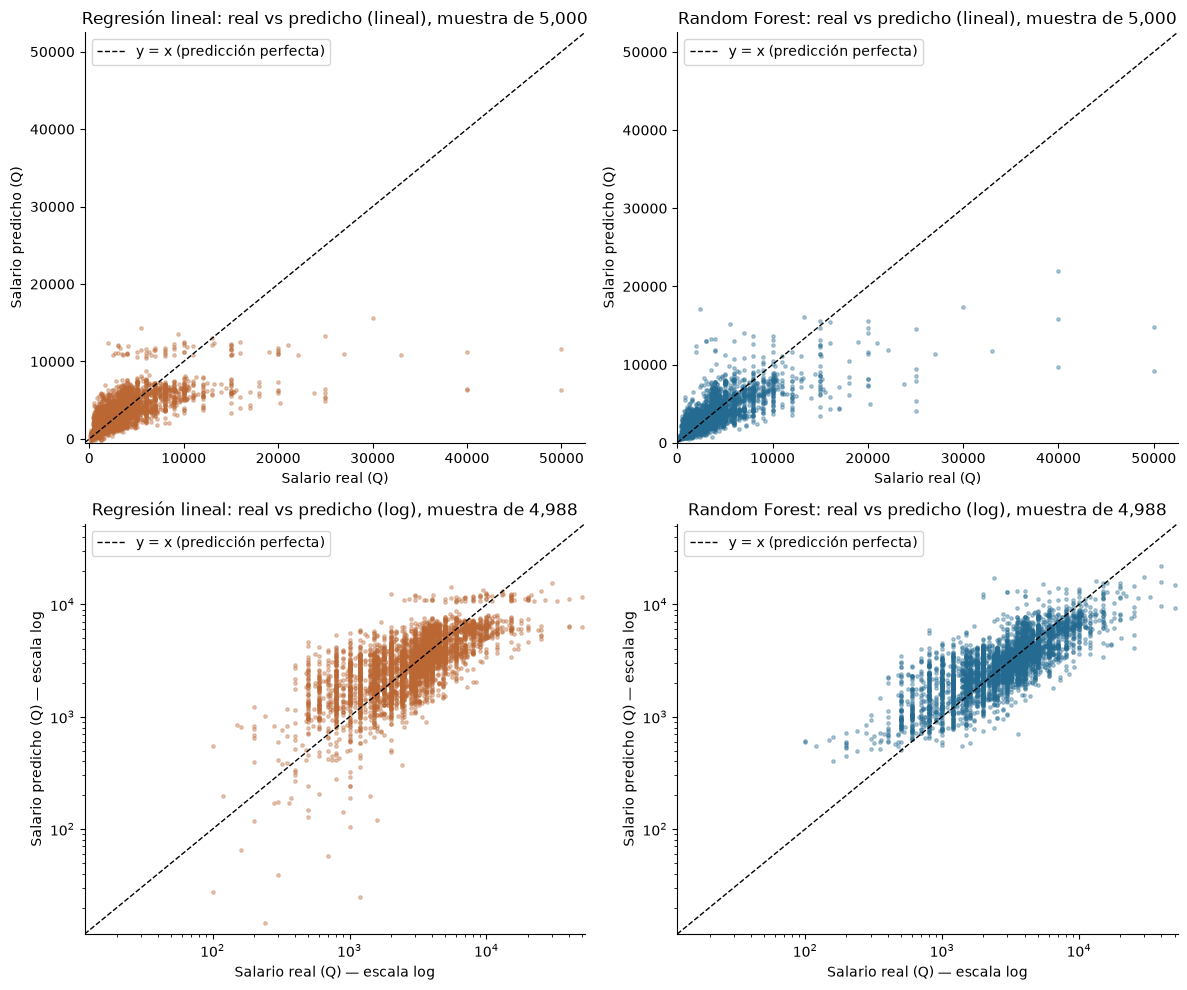

In [6]:
muestra = (predicciones.sample(fraction=min(1.0, 1.2 * TAMANIO_MUESTRA / n_prueba), seed=SEMILLA)
           .limit(TAMANIO_MUESTRA)
           .select(ETIQUETA, 'pred_lr', 'pred_rf', 'residuo_lr', 'residuo_rf').toPandas())
assert len(muestra) <= TAMANIO_MUESTRA
PARES = [('Regresión lineal', 'pred_lr', 'residuo_lr', '#ba6734'), ('Random Forest', 'pred_rf', 'residuo_rf', '#246a91')]

limite = max(muestra[ETIQUETA].max(), muestra.pred_lr.max(), muestra.pred_rf.max()) * 1.05
positivos = muestra[(muestra.pred_lr > 0) & (muestra.pred_rf > 0)]
bajo = min(positivos[ETIQUETA].min(), positivos.pred_lr.min(), positivos.pred_rf.min()) * 0.8

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for j, (nombre, pred, _, color) in enumerate(PARES):
    for i, escala in enumerate(['lineal', 'log']):
        eje = axes[i, j]
        datos = muestra if escala == 'lineal' else positivos
        eje.scatter(datos[ETIQUETA], datos[pred], s=6, alpha=0.35, color=color)
        extremo = (min(0, muestra[pred].min()), limite) if escala == 'lineal' else (bajo, limite)
        eje.plot(extremo, extremo, color='black', linestyle='--', linewidth=1, label='y = x (predicción perfecta)')
        eje.set_xlim(extremo)
        eje.set_ylim(extremo)
        if escala == 'log':
            eje.set_xscale('log')
            eje.set_yscale('log')
        eje.set(xlabel='Salario real (Q)' + (' — escala log' if escala == 'log' else ''),
                ylabel='Salario predicho (Q)' + (' — escala log' if escala == 'log' else ''),
                title=f'{nombre}: real vs predicho ({escala}), muestra de {len(datos):,}')
        eje.legend(loc='upper left')
guardar_grafica('evaluacion_real_vs_predicho')

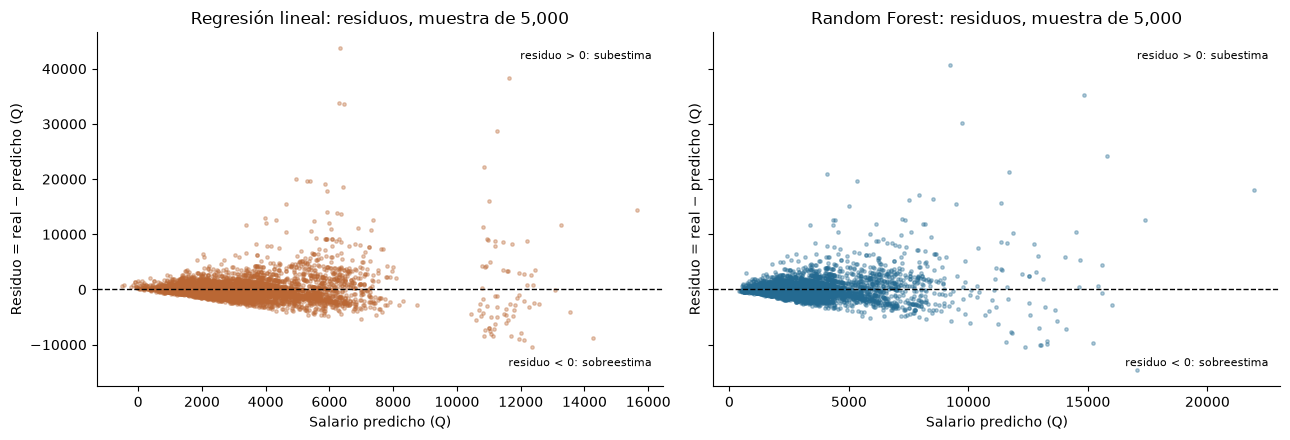

,modelo,error_medio,residuo_mediano,residuo_p05,residuo_p95,desviacion,asimetria,pct_subestimados
0,Regresión lineal,120.551022,-30.941827,-2303.211367,2933.655419,2160.472389,4.705192,48.944034
1,Random Forest,109.584619,-49.671800,-2075.658208,2617.707722,1926.385035,4.314318,47.812641


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for eje, (nombre, pred, residuo, color) in zip(axes, PARES):
    eje.scatter(muestra[pred], muestra[residuo], s=6, alpha=0.35, color=color)
    eje.axhline(0, color='black', linestyle='--', linewidth=1)
    eje.set(xlabel='Salario predicho (Q)', ylabel='Residuo = real − predicho (Q)',
            title=f'{nombre}: residuos, muestra de {len(muestra):,}')
    eje.text(0.98, 0.95, 'residuo > 0: subestima', transform=eje.transAxes, ha='right', va='top', fontsize=8)
    eje.text(0.98, 0.05, 'residuo < 0: sobreestima', transform=eje.transAxes, ha='right', va='bottom', fontsize=8)
guardar_grafica('evaluacion_residuos')

resumen_residuos = []
for nombre, _, residuo, _ in PARES:
    r = predicciones.agg(
        F.mean(residuo).alias('error_medio'),
        F.expr(f'percentile({residuo}, array(0.05, 0.5, 0.95))').alias('p'),
        F.stddev_samp(residuo).alias('desviacion'),
        F.skewness(residuo).alias('asimetria'),
        (100 * F.avg((F.col(residuo) > 0).cast('int'))).alias('pct_subestimados'),
    ).first()
    resumen_residuos.append({'modelo': nombre, 'error_medio': r.error_medio, 'residuo_mediano': r.p[1],
                             'residuo_p05': r.p[0], 'residuo_p95': r.p[2], 'desviacion': r.desviacion,
                             'asimetria': r.asimetria, 'pct_subestimados': r.pct_subestimados})
resumen_residuos = pd.DataFrame(resumen_residuos)
tabla(resumen_residuos, 'evaluacion_resumen_residuos')

**Regresión lineal:** error medio **Q+121** y residuo mediano **Q-31**; subestima en el **48.9%** de los registros. El 90% central de los residuos va de Q-2,303 a Q+2,934 y su asimetría es 4.71: los errores **no son simétricos**; hay pocas subestimaciones muy grandes (salarios altos) y muchas sobreestimaciones moderadas.

**Random Forest:** error medio **Q+110** y residuo mediano **Q-50**; subestima en el **47.8%** de los registros. El 90% central de los residuos va de Q-2,076 a Q+2,618 y su asimetría es 4.31: los errores **no son simétricos**; hay pocas subestimaciones muy grandes (salarios altos) y muchas sobreestimaciones moderadas.

### 8.2 Errores por nivel educativo y por dominio
Calculados con **todos** los registros de prueba. *Error medio* = promedio del residuo:
positivo indica que el grupo se subestima en promedio; negativo, que se sobreestima.

**Por nivel educativo**

,nivel_educativo,etiqueta,n,salario_mediano,mae_lr,error_medio_lr,mae_rf,error_medio_rf
0,0,NINGUNO,1016,1680.0,823.51,109.34,628.16,49.71
1,1,PREPRIMARIA,80,2400.0,735.21,88.76,573.61,-21.44
2,2,PRIMARIA,3957,2400.0,870.04,54.56,746.36,52.63
3,3,BÁSICO,2164,3000.0,894.45,127.77,799.29,131.90
4,4,DIVERSIFICADO,4117,3800.0,1109.31,103.98,1005.26,103.53
5,5,SUPERIOR,1729,5000.0,2566.37,295.51,2253.05,257.87
6,6,MAESTRÍA,183,10000.0,5552.88,-131.50,4572.48,-213.22
7,7,DOCTORADO,12,18500.0,12919.31,6062.70,10606.10,6442.29


**Por dominio**

,dominio,etiqueta,n,salario_mediano,mae_lr,error_medio_lr,mae_rf,error_medio_rf
0,1,Urbano Metropolitano,5632,3900.0,1446.09,136.04,1299.48,155.03
1,2,Resto Urbano,4846,3000.0,1189.65,134.28,1021.96,95.06
2,3,Rural Nacional,2780,2160.0,913.64,65.24,753.31,42.83


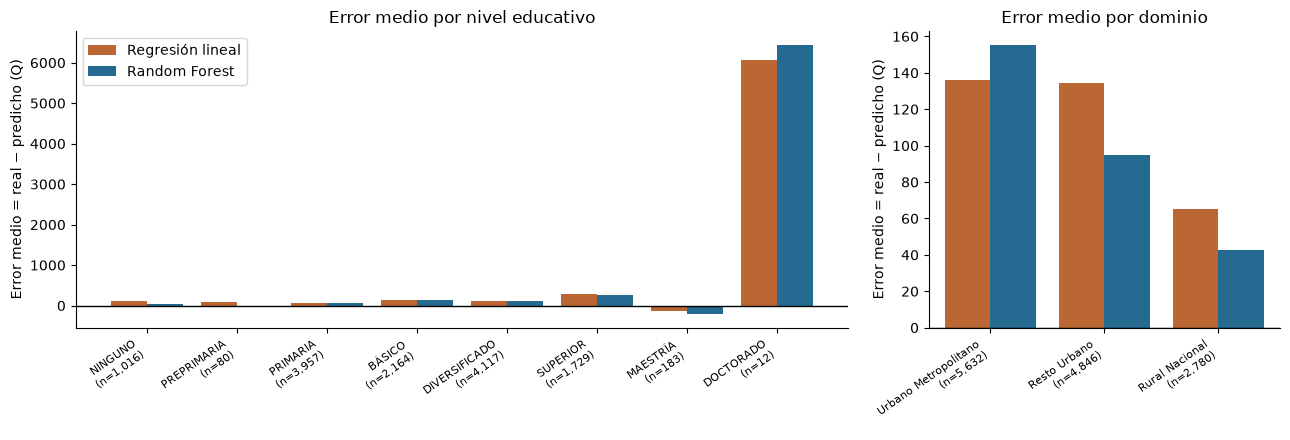

In [8]:
def errores_por_grupo(variable):
    agregado = (predicciones.groupBy(variable).agg(
            F.count('*').alias('n'),
            F.expr(f'percentile({ETIQUETA}, 0.5)').alias('salario_mediano'),
            F.mean(F.abs('residuo_lr')).alias('mae_lr'), F.mean('residuo_lr').alias('error_medio_lr'),
            F.mean(F.abs('residuo_rf')).alias('mae_rf'), F.mean('residuo_rf').alias('error_medio_rf'))
        .orderBy(variable).toPandas())
    agregado.insert(1, 'etiqueta', agregado[variable].map(etiquetas_diccionario(variable)).fillna(agregado[variable]))
    return agregado

por_grupo = {}
for variable in ['nivel_educativo', 'dominio']:
    por_grupo[variable] = errores_por_grupo(variable)
    explicar(f'**Por {variable.replace("_", " ")}**')
    tabla(por_grupo[variable].round(2), f'evaluacion_errores_{variable}')

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), gridspec_kw={'width_ratios': [2.2, 1]})
for eje, variable in zip(axes, ['nivel_educativo', 'dominio']):
    d = por_grupo[variable]
    x = np.arange(len(d))
    eje.bar(x - 0.2, d.error_medio_lr, width=0.4, label='Regresión lineal', color='#ba6734')
    eje.bar(x + 0.2, d.error_medio_rf, width=0.4, label='Random Forest', color='#246a91')
    eje.axhline(0, color='black', linewidth=1)
    eje.set_xticks(x, [f'{e}\n(n={n:,})' for e, n in zip(d.etiqueta, d.n)], rotation=35, ha='right', fontsize=8)
    eje.set(ylabel='Error medio = real − predicho (Q)', title=f'Error medio por {variable.replace("_", " ")}')
axes[0].legend()
guardar_grafica('evaluacion_error_por_grupo')

El mayor MAE de Random Forest por nivel educativo se da en **DOCTORADO** (Q10,606, n=12), con error medio Q+6,442. Los grupos con salarios medianos más altos concentran los errores absolutos más grandes porque su dispersión salarial también es mayor; los grupos pequeños (maestría, doctorado) deben leerse con cautela por su n. Por dominio, el MAE de Random Forest va de Q753 a Q1,299.

### 8.3 Errores por percentil del salario real

Se cortan los salarios reales de 2026T1 en sus percentiles exactos (P10, P25, P50, P75, P90, P95 y P99)
y se calcula, para cada tramo y modelo, el error medio, el MAE y el porcentaje de registros subestimados.
Así se evalúa si los modelos tienden a subestimar los salarios altos y sobreestimar los bajos.

,percentil,salario_Q
0,P10,1000.0
1,P25,2000.0
2,P50,3200.0
3,P75,4080.0
4,P90,6000.0
5,P95,8000.0
6,P99,15000.0


,tramo,tramo_salario,n,salario_real_medio,prediccion_media_lr,prediccion_media_rf,error_medio_lr,error_medio_rf,mae_lr,mae_rf,pct_subestimados_lr,pct_subestimados_rf
0,0,"≤P10 (≤Q1,000)",1486,735.4,1722.5,1575.7,-987.1,-840.2,1070.5,858.4,13.5,6.1
1,1,"P10–P25 (Q1,000–2,000]",2546,1625.8,2362.2,2285.8,-736.3,-659.9,956.3,801.0,25.7,23.3
2,2,"P25–P50 (Q2,000–3,200]",2715,2738.2,2899.3,2881.2,-161.1,-143.1,851.7,684.8,47.4,47.4
3,3,"P50–P75 (Q3,200–4,080]",3200,3770.2,3852.3,3821.2,-82.1,-51.0,832.9,743.4,55.0,55.8
4,4,"P75–P90 (Q4,080–6,000]",2060,4893.3,4400.0,4427.0,493.3,466.3,1176.4,1172.1,69.6,71.3
5,5,"P90–P95 (Q6,000–8,000]",608,7224.8,5590.5,5755.5,1634.3,1469.3,2076.1,1914.4,90.1,84.4
6,6,"P95–P99 (Q8,000–15,000]",545,10722.7,6630.9,7274.8,4091.7,3447.9,4331.3,3731.0,93.4,92.1
7,7,">P99 (>Q15,000)",98,22730.0,8444.6,10482.6,14285.4,12247.4,14285.4,12247.4,100.0,100.0


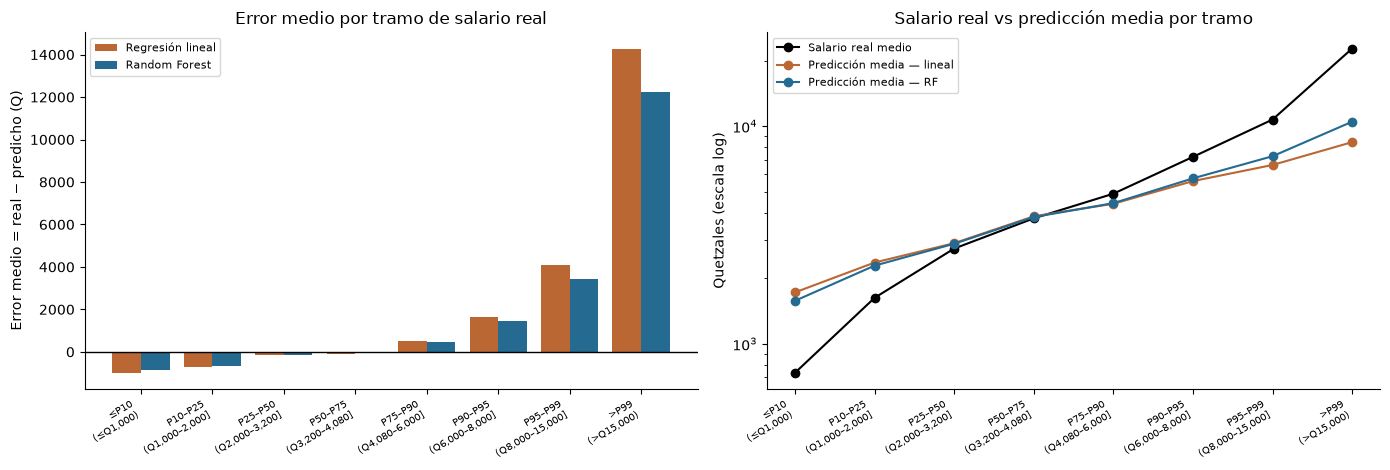

In [9]:
PERCENTILES = [('P10', 0.10), ('P25', 0.25), ('P50', 0.50), ('P75', 0.75), ('P90', 0.90), ('P95', 0.95), ('P99', 0.99)]
valores = predicciones.agg(
    F.expr(f"percentile({ETIQUETA}, array({', '.join(str(q) for _, q in PERCENTILES)}))")).first()[0]
display(pd.DataFrame({'percentil': [p for p, _ in PERCENTILES], 'salario_Q': valores}))

limites = []
for (nombre, _), valor in zip(PERCENTILES, valores):
    if limites and valor <= limites[-1][1]:
        limites[-1] = (nombre, valor)   # empate entre percentiles: se fusiona el tramo
    else:
        limites.append((nombre, valor))

expresion = F.lit(len(limites))
for i, (_, valor) in reversed(list(enumerate(limites))):
    expresion = F.when(F.col(ETIQUETA) <= valor, F.lit(i)).otherwise(expresion)
nombres_tramo = [f'≤{limites[0][0]}\n(≤Q{limites[0][1]:,.0f})']
nombres_tramo += [f'{limites[i - 1][0]}–{limites[i][0]}\n(Q{limites[i - 1][1]:,.0f}–{limites[i][1]:,.0f}]'
                  for i in range(1, len(limites))]
nombres_tramo += [f'>{limites[-1][0]}\n(>Q{limites[-1][1]:,.0f})']

por_tramo = (predicciones.withColumn('tramo', expresion).groupBy('tramo').agg(
        F.count('*').alias('n'),
        F.mean(ETIQUETA).alias('salario_real_medio'),
        F.mean('pred_lr').alias('prediccion_media_lr'), F.mean('pred_rf').alias('prediccion_media_rf'),
        F.mean('residuo_lr').alias('error_medio_lr'), F.mean('residuo_rf').alias('error_medio_rf'),
        F.mean(F.abs('residuo_lr')).alias('mae_lr'), F.mean(F.abs('residuo_rf')).alias('mae_rf'),
        (100 * F.avg((F.col('residuo_lr') > 0).cast('int'))).alias('pct_subestimados_lr'),
        (100 * F.avg((F.col('residuo_rf') > 0).cast('int'))).alias('pct_subestimados_rf'))
    .orderBy('tramo').toPandas())
por_tramo.insert(1, 'tramo_salario', [nombres_tramo[t].replace('\n', ' ') for t in por_tramo.tramo])
assert int(por_tramo.n.sum()) == n_prueba
tabla(por_tramo.round(1), 'evaluacion_errores_por_percentil')

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
x = np.arange(len(por_tramo))
etiquetas_x = [nombres_tramo[t] for t in por_tramo.tramo]
axes[0].bar(x - 0.2, por_tramo.error_medio_lr, width=0.4, label='Regresión lineal', color='#ba6734')
axes[0].bar(x + 0.2, por_tramo.error_medio_rf, width=0.4, label='Random Forest', color='#246a91')
axes[0].axhline(0, color='black', linewidth=1)
axes[0].set(ylabel='Error medio = real − predicho (Q)', title='Error medio por tramo de salario real')
axes[1].plot(x, por_tramo.salario_real_medio, marker='o', color='black', label='Salario real medio')
axes[1].plot(x, por_tramo.prediccion_media_lr, marker='o', color='#ba6734', label='Predicción media — lineal')
axes[1].plot(x, por_tramo.prediccion_media_rf, marker='o', color='#246a91', label='Predicción media — RF')
axes[1].set_yscale('log')
axes[1].set(ylabel='Quetzales (escala log)', title='Salario real vs predicción media por tramo')
for eje in axes:
    eje.set_xticks(x, etiquetas_x, fontsize=7, rotation=30, ha='right')
    eje.legend(fontsize=8)
guardar_grafica('evaluacion_errores_por_percentil')

En el tramo más bajo (≤P10 (≤Q1,000)), el salario real medio es Q735 y el error medio es **Q-987** (lineal) y **Q-840** (RF): los modelos **sobreestiman** los salarios bajos. En el tramo más alto (>P99 (>Q15,000)), el salario real medio es Q22,730, pero la predicción media es Q8,445 (lineal) y Q10,483 (RF); el error medio es **Q+14,285** y **Q+12,247**, y se subestima al 100% de esos registros con RF. Por encima de P95 hay 643 registros (4.8% de la prueba).

**Lectura:** los modelos comprimen las predicciones hacia el centro de la distribución (regresión a la media). Con sólo seis predictores, dos personas con la misma edad, antigüedad, horas, educación, categoría y dominio pueden tener salarios muy distintos, y el modelo les asigna un valor intermedio. Como la distribución salarial es muy asimétrica a la derecha, esa compresión produce pocas subestimaciones muy grandes en la cola alta, que dominan el RMSE, y muchas sobreestimaciones moderadas en los salarios bajos.

## Discusión final

1. **Datos (actividades 1–2).** La población analítica son asalariados con salario positivo registrado; su salario es muy asimétrico
   a la derecha y conserva extremos por instrucción. Esa forma de la distribución condiciona todas las métricas: el RMSE pesa mucho
   los pocos salarios altos.
2. **Relaciones y perfiles (actividades 3–4).** Las variables numéricas tienen correlaciones débiles con el salario. La segmentación KMeans (actividad 4, K=5, silhouette 0.484) identificó perfiles como Veteranos estables, Jornada extensa, Jornada parcial, Adultos con poca antigüedad, Jóvenes en inicio laboral; aunque se formaron sin salario, sus medianas salariales difieren de forma importante, en particular la jornada parcial. Esto es coherente con que las horas y la estabilidad aporten información, pero no basten para explicar todo el salario. 
3. **Modelos (actividades 5–7).** Random Forest supera a la regresión lineal y ambos superan al baseline, tanto en 2025T4 como en 2026T1.
   En la prueba final, random forest obtiene RMSE Q1,929 y R² 0.547. La ventaja del bosque se explica por su
   capacidad de representar interacciones y relaciones no lineales entre educación, categoría, dominio, edad, antigüedad y horas.
   La regularización no aportó mejoras porque, con más de 40 mil registros y pocas variables, la regresión lineal no sobreajusta.
4. **Errores (actividad 8).** Los errores no son simétricos: ambos modelos sobreestiman los salarios bajos y subestiman sistemáticamente los
   salarios altos, sobre todo por encima de P95. Los grupos con salarios más altos y dispersos (educación superior y posgrado,
   dominio urbano metropolitano) concentran los mayores errores absolutos.
5. **Limitaciones.** R² cercano a 0.5 indica que la mitad de la variación salarial depende de factores no incluidos (sector, tamaño de la
   empresa, ocupación específica, experiencia previa, región fina, negociación). Los resultados no están ponderados por FACTOR, los salarios
   son nominales y las asociaciones no son causales. La predicción es del salario del período observado, no un pronóstico individual.
6. **Posibles mejoras** (fuera de la comparación obligatoria): modelar el log del salario o la mediana (regresión cuantílica), agregar
   variables de ocupación y rama de actividad, y evaluar con ponderación por FACTOR si el objetivo fuera poblacional.

In [10]:
entrenamiento_final.unpersist()
prueba.unpersist()
predicciones.unpersist()
print('Actividades 7 y 8 terminadas. Resultados en:', OUT)

Actividades 7 y 8 terminadas. Resultados en: /opt/app/laboratorio/Transform_Data
